# EDA of the merged listed dataset

## 1. Dataset Understanding

In [1]:
import pandas as pd 

df = pd.read_csv('../../processed/sold/sold_cleaned_v1.csv')

In [2]:
print("Number of rows and columns:", df.shape)
print("\nColumn data types summary:")
print(df.dtypes.value_counts())
print("\nHigh-missing columns (>50% missing):")
missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 50].sort_values(ascending=False)
print(high_missing)
print(f"\nTotal columns with >50% missing: {len(high_missing)}")

Number of rows and columns: (17963, 80)

Column data types summary:
object     50
float64    27
int64       3
Name: count, dtype: int64

High-missing columns (>50% missing):
MiddleOrJuniorSchoolDistrict    100.000000
FireplacesTotal                 100.000000
CoveredSpaces                   100.000000
ElementarySchoolDistrict        100.000000
AboveGradeFinishedArea          100.000000
WaterfrontYN                     99.944330
TaxYear                          99.899794
BelowGradeFinishedArea           99.699382
BusinessType                     99.632578
TaxAnnualAmount                  99.404331
BasementYN                       98.530312
BuilderName                      96.136503
LotSizeDimensions                94.694650
CoBuyerAgentFirstName            92.356511
ElementarySchool                 89.845794
MiddleOrJuniorSchool             89.656516
HighSchool                       86.282915
BuildingAreaTotal                86.249513
CoListAgentFirstName             81.016534
CoListAge

In [3]:
print("All column names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

All column names:
 1. BuyerAgentAOR
 2. ListAgentAOR
 3. Flooring
 4. ViewYN
 5. WaterfrontYN
 6. BasementYN
 7. PoolPrivateYN
 8. OriginalListPrice
 9. ListingKey
10. ListAgentEmail
11. CloseDate
12. ClosePrice
13. ListAgentFirstName
14. ListAgentLastName
15. Latitude
16. Longitude
17. UnparsedAddress
18. PropertyType
19. LivingArea
20. ListPrice
21. DaysOnMarket
22. ListOfficeName
23. BuyerOfficeName
24. CoListOfficeName
25. ListAgentFullName
26. CoListAgentFirstName
27. CoListAgentLastName
28. BuyerAgentMlsId
29. BuyerAgentFirstName
30. BuyerAgentLastName
31. FireplacesTotal
32. AssociationFeeFrequency
33. AboveGradeFinishedArea
34. ListingKeyNumeric
35. MLSAreaMajor
36. TaxAnnualAmount
37. CountyOrParish
38. MlsStatus
39. ElementarySchool
40. AttachedGarageYN
41. ParkingTotal
42. BuilderName
43. PropertySubType
44. LotSizeAcres
45. SubdivisionName
46. BuyerOfficeAOR
47. YearBuilt
48. StreetNumberNumeric
49. ListingId
50. BathroomsTotalInteger
51. City
52. TaxYear
53. BuildingAreaTo

In [22]:
# Separate market analysis fields from metadata fields
market_analysis_fields = [
    'OriginalListPrice', 'ListPrice', 'ClosePrice', 'LivingArea', 'LotSizeAcres',
    'LotSizeArea', 'LotSizeSquareFeet', 'BuildingAreaTotal', 'BedroomsTotal',
    'BathroomsTotalInteger', 'MainLevelBedrooms', 'Latitude', 'Longitude',
    'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'PropertyType',
    'PropertySubType', 'YearBuilt', 'Stories', 'Levels', 'AttachedGarageYN',
    'ParkingTotal', 'GarageSpaces', 'FireplaceYN', 'NewConstructionYN', 'DaysOnMarket', 'BelowGradeFinishedArea',
    'AboveGradeFinishedArea', 'TaxAnnualAmount', 
    'BasementYN',
    'CoveredSpaces',
    'WaterfrontYN',
    'PoolPrivateYN',
    'ViewYN',
    'FireplacesTotal',
    'Flooring'
]

metadata_fields = [
    'ListingKey', 'ListingKeyNumeric', 'ListingId', 'ListAgentEmail',
    'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName',
    'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'CoBuyerAgentFirstName',
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'BuyerOfficeAOR',
    'CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate',
    'ListingContractDate', 'UnparsedAddress', 'StreetNumberNumeric',
    'StateOrProvince', 'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
    'HighSchoolDistrict', 'SubdivisionName', 'BuilderName', 'AssociationFee',
    'AssociationFeeFrequency', 'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType', 'LotSizeDimensions', 'MlsStatus',
    'source_file', 'source_month', 'ListAgentAOR',
    'BuyerAgentAOR',
    'OriginatingSystemName',
    'OriginatingSystemSubName', 'ElementarySchoolDistrict',
    'MiddleOrJuniorSchoolDistrict', 'BusinessType',
    'TaxYear'
]

print("Market Analysis Fields:")
for field in market_analysis_fields:
    print(f"  - {field}")

print(f"\nTotal Market Analysis Fields: {len(market_analysis_fields)}")

print("\nMetadata Fields:")
for field in metadata_fields:
    print(f"  - {field}")

print(f"\nTotal Metadata Fields: {len(metadata_fields)}")

# Verify all columns are covered
all_classified = set(market_analysis_fields + metadata_fields)
all_columns = set(df.columns)
if all_classified == all_columns:
    print("\n✓ All columns have been classified.")
else:
    print(f"\n⚠ Unclassified columns: {all_columns - all_classified}")

Market Analysis Fields:
  - OriginalListPrice
  - ListPrice
  - ClosePrice
  - LivingArea
  - LotSizeAcres
  - LotSizeArea
  - LotSizeSquareFeet
  - BuildingAreaTotal
  - BedroomsTotal
  - BathroomsTotalInteger
  - MainLevelBedrooms
  - Latitude
  - Longitude
  - City
  - PostalCode
  - CountyOrParish
  - MLSAreaMajor
  - PropertyType
  - PropertySubType
  - YearBuilt
  - Stories
  - Levels
  - AttachedGarageYN
  - ParkingTotal
  - GarageSpaces
  - FireplaceYN
  - NewConstructionYN
  - DaysOnMarket
  - BelowGradeFinishedArea
  - AboveGradeFinishedArea
  - TaxAnnualAmount
  - BasementYN
  - CoveredSpaces
  - WaterfrontYN
  - PoolPrivateYN
  - ViewYN
  - FireplacesTotal
  - Flooring

Total Market Analysis Fields: 38

Metadata Fields:
  - ListingKey
  - ListingKeyNumeric
  - ListingId
  - ListAgentEmail
  - ListAgentFirstName
  - ListAgentLastName
  - ListAgentFullName
  - CoListAgentFirstName
  - CoListAgentLastName
  - BuyerAgentMlsId
  - BuyerAgentFirstName
  - BuyerAgentLastName
  - C

## 2. Missing Value Analysis

In [5]:
missing_count = df.isnull().sum()
missing_pct = df.isnull().sum() / len(df) * 100

missing_report = pd.DataFrame({'missing_counts': missing_count, 'missing_pct': missing_pct})
missing_report = missing_report.sort_values(by='missing_pct', ascending=False) 

import numpy as np
missing_report['missing_flag'] = np.where(
    missing_report['missing_pct'] > 90,
    'high_missing',
    ''
) 
missing_report

,missing_counts,missing_pct,missing_flag
FireplacesTotal,17963,100.0,high_missing
MiddleOrJuniorSchoolDistrict,17963,100.0,high_missing
ElementarySchoolDistrict,17963,100.0,high_missing
AboveGradeFinishedArea,17963,100.0,high_missing
CoveredSpaces,17963,100.0,high_missing
...,...,...,...
ListingKeyNumeric,0,0.0,
CountyOrParish,0,0.0,
MlsStatus,0,0.0,
ListingId,0,0.0,


In [6]:
high_missing = missing_report[missing_report['missing_flag'] == 'high_missing']
high_missing

,missing_counts,missing_pct,missing_flag
FireplacesTotal,17963,100.000000,high_missing
MiddleOrJuniorSchoolDistrict,17963,100.000000,high_missing
ElementarySchoolDistrict,17963,100.000000,high_missing
AboveGradeFinishedArea,17963,100.000000,high_missing
CoveredSpaces,17963,100.000000,high_missing
WaterfrontYN,17953,99.944330,high_missing
TaxYear,17945,99.899794,high_missing
BelowGradeFinishedArea,17909,99.699382,high_missing
BusinessType,17897,99.632578,high_missing
TaxAnnualAmount,17856,99.404331,high_missing


In [23]:
cols_to_drop = [
    high_missing[high_missing['missing_flag'] == 'high_missing']
]
cols_to_drop = high_missing.index.tolist()
cols_to_drop

['FireplacesTotal',
 'MiddleOrJuniorSchoolDistrict',
 'ElementarySchoolDistrict',
 'AboveGradeFinishedArea',
 'CoveredSpaces',
 'WaterfrontYN',
 'TaxYear',
 'BelowGradeFinishedArea',
 'BusinessType',
 'TaxAnnualAmount',
 'BasementYN',
 'BuilderName',
 'LotSizeDimensions',
 'CoBuyerAgentFirstName']

In [24]:
df = df.drop(columns=cols_to_drop)
df.shape

(17963, 66)

## 3. Numeric Distribution Review

In [29]:
numeric_cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

In [30]:
for col in numeric_cols:
    print(df[col].value_counts())

ClosePrice
3500.0      143
4500.0      132
3000.0      124
650000.0    121
4000.0      109
           ... 
113750.0      1
637070.0      1
537500.0      1
823000.0      1
46500.0       1
Name: count, Length: 3404, dtype: int64
ListPrice
3500.0      150
799000.0    131
699000.0    128
4500.0      127
599000.0    111
           ... 
604950.0      1
133000.0      1
4287.0        1
10950.0       1
448888.0      1
Name: count, Length: 3416, dtype: int64
OriginalListPrice
3500.0       152
799000.0     138
699000.0     120
4500.0       120
599000.0     111
            ... 
814900.0       1
1689900.0      1
2890000.0      1
3597000.0      1
73900.0        1
Name: count, Length: 3305, dtype: int64
LivingArea
1440.0    117
1200.0    109
1000.0    105
800.0      96
900.0      83
         ... 
4925.0      1
5806.0      1
3444.0      1
4963.0      1
3732.0      1
Name: count, Length: 3383, dtype: int64
LotSizeAcres
0.0000     428
0.1700     237
0.1400     214
0.1600     201
0.1800     173
         

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

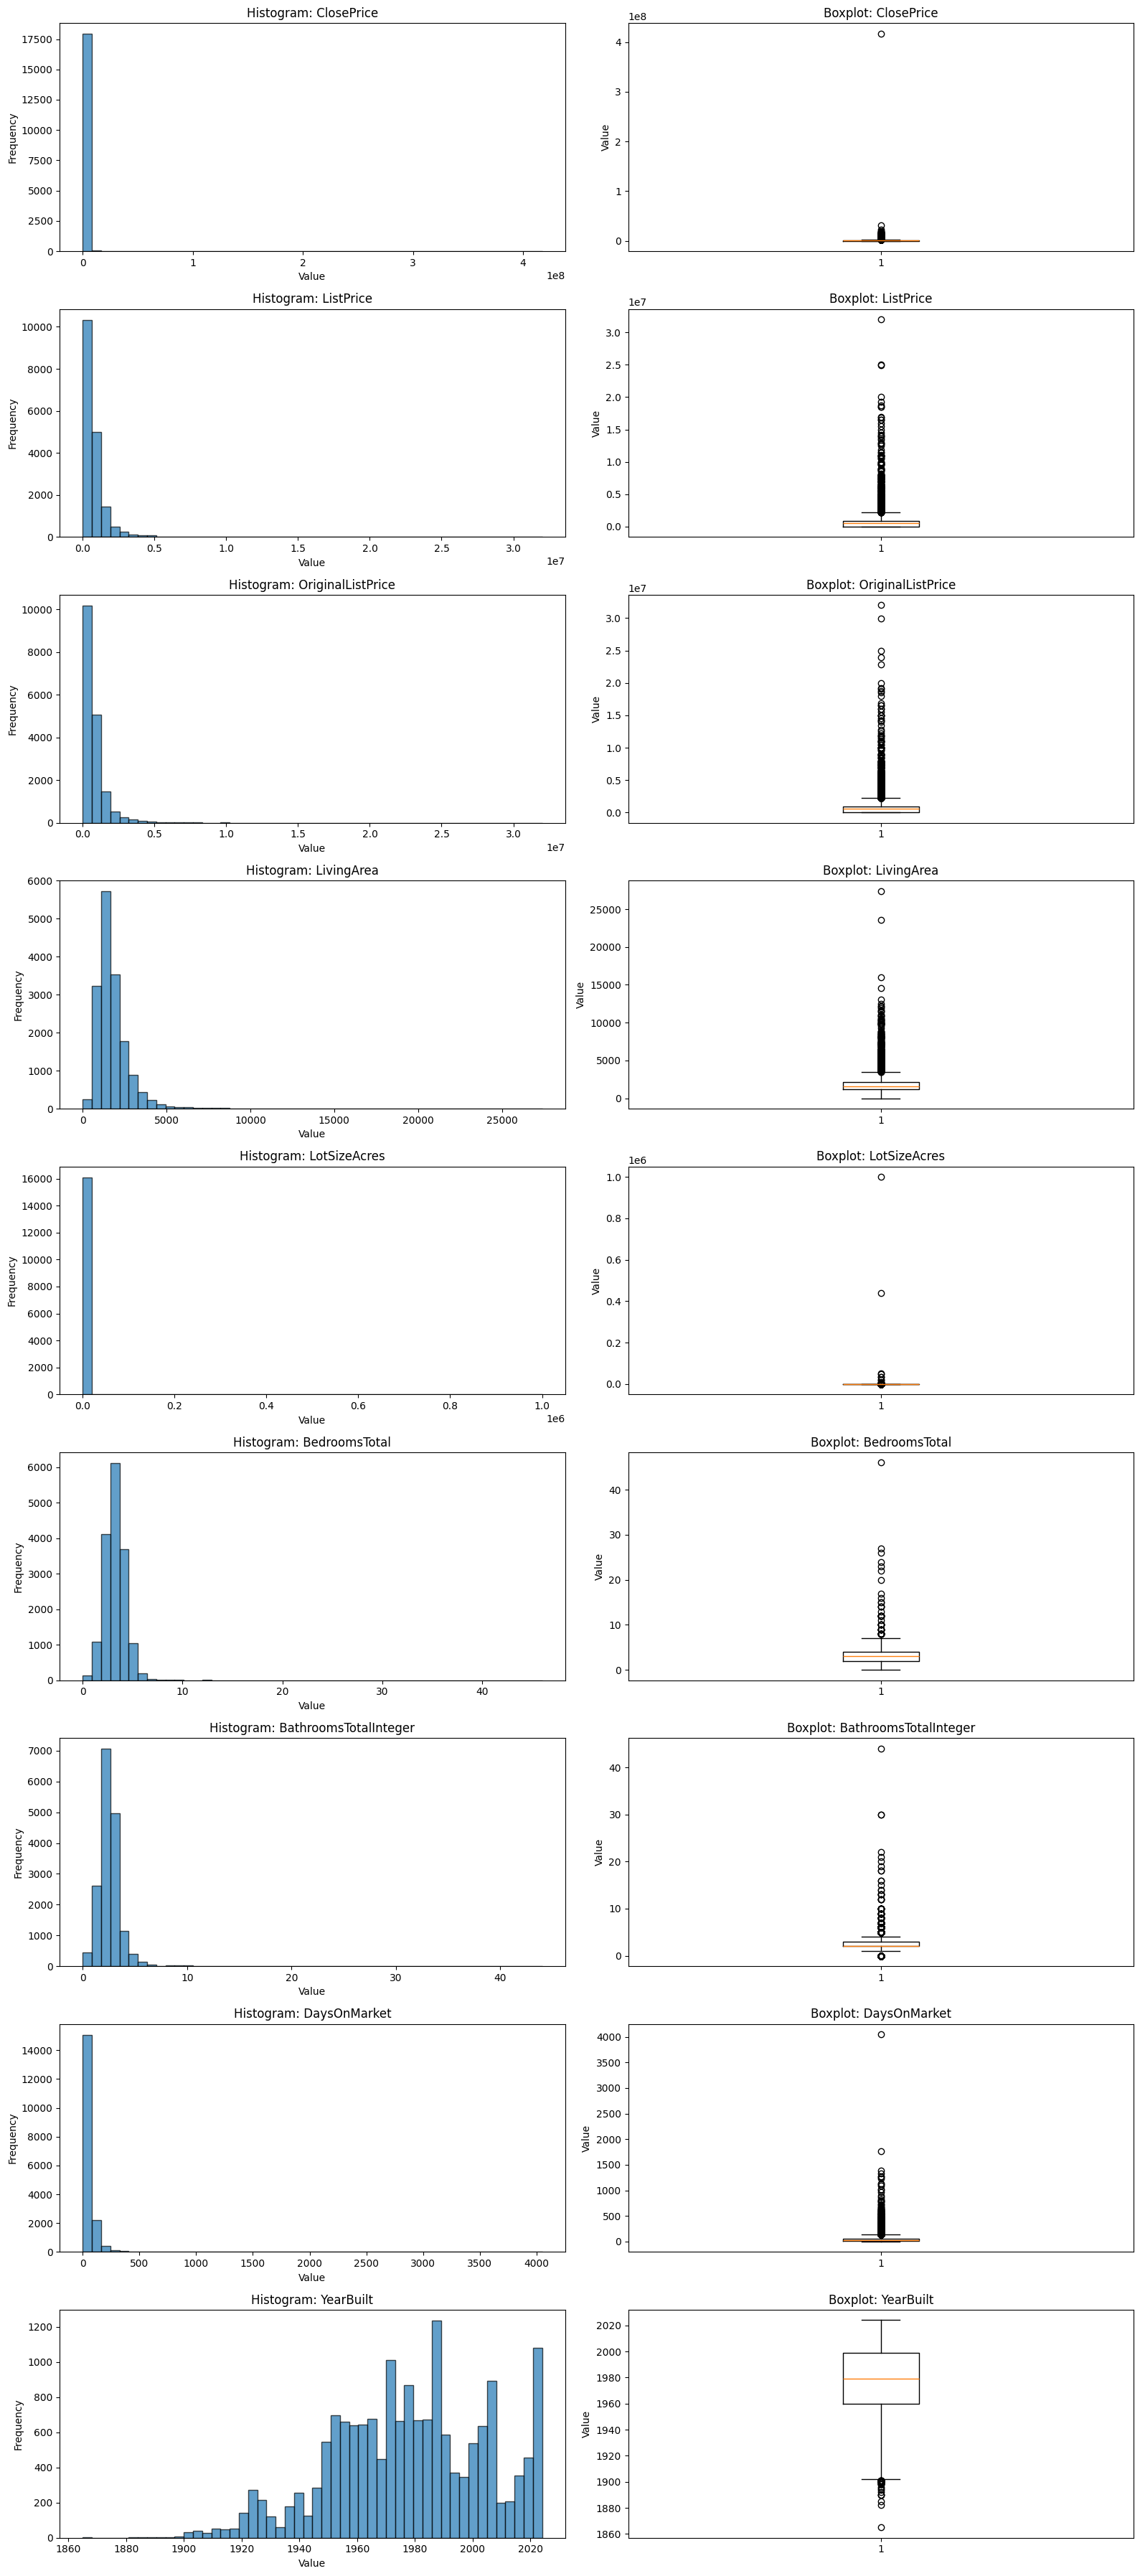

In [33]:
# Create comprehensive numeric analysis
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(16, 4*len(numeric_cols)))

for idx, col in enumerate(numeric_cols):
    # Histogram
    axes[idx, 0].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Histogram: {col}')
    axes[idx, 0].set_xlabel('Value')
    axes[idx, 0].set_ylabel('Frequency')
    
    # Boxplot
    axes[idx, 1].boxplot(df[col].dropna(), vert=True)
    axes[idx, 1].set_title(f'Boxplot: {col}')
    axes[idx, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [34]:
# Generate percentile summaries and outlier analysis
print("=" * 80)
print("PERCENTILE SUMMARIES AND OUTLIER DETECTION")
print("=" * 80)

outliers_summary = []

for col in numeric_cols:
    print(f"\n{col}:")
    print("-" * 80)
    
    # Get non-null values
    valid_data = df[col].dropna()
    
    if len(valid_data) == 0:
        print("  No valid data")
        continue
    
    # Percentile summary
    percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
    print("\nPercentile Summary:")
    for p in percentiles:
        value = np.percentile(valid_data, p)
        print(f"  {p:3d}th percentile: {value:15,.2f}")
    
    # Basic statistics
    print(f"\nBasic Statistics:")
    print(f"  Mean:     {valid_data.mean():15,.2f}")
    print(f"  Median:   {valid_data.median():15,.2f}")
    print(f"  Std Dev:  {valid_data.std():15,.2f}")
    print(f"  Min:      {valid_data.min():15,.2f}")
    print(f"  Max:      {valid_data.max():15,.2f}")
    
    # IQR-based outlier detection
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = valid_data[(valid_data < lower_bound) | (valid_data > upper_bound)]
    
    # Extreme outliers (beyond 3*IQR)
    extreme_lower = Q1 - 3 * IQR
    extreme_upper = Q3 + 3 * IQR
    extreme_outliers = valid_data[(valid_data < extreme_lower) | (valid_data > extreme_upper)]
    
    print(f"\nOutlier Analysis (IQR method):")
    print(f"  IQR:           {IQR:15,.2f}")
    print(f"  Lower Bound:   {lower_bound:15,.2f}")
    print(f"  Upper Bound:   {upper_bound:15,.2f}")
    print(f"  Outliers:      {len(outliers):15,} ({len(outliers)/len(valid_data)*100:5.2f}%)")
    print(f"  Extreme Lower: {extreme_lower:15,.2f}")
    print(f"  Extreme Upper: {extreme_upper:15,.2f}")
    print(f"  Extreme Outliers: {len(extreme_outliers):10,} ({len(extreme_outliers)/len(valid_data)*100:5.2f}%)")
    
    outliers_summary.append({
        'Column': col,
        'Total_Values': len(valid_data),
        'Outliers_Count': len(outliers),
        'Outliers_Percent': f"{len(outliers)/len(valid_data)*100:.2f}%",
        'Extreme_Outliers': len(extreme_outliers),
        'Extreme_Percent': f"{len(extreme_outliers)/len(valid_data)*100:.2f}%"
    })

PERCENTILE SUMMARIES AND OUTLIER DETECTION

ClosePrice:
--------------------------------------------------------------------------------

Percentile Summary:
    0th percentile:            1.30
    1th percentile:        1,700.00
    5th percentile:        2,500.00
   25th percentile:        8,600.00
   50th percentile:      540,000.00
   75th percentile:      902,500.00
   95th percentile:    2,150,000.00
   99th percentile:    4,409,500.00
  100th percentile:  417,255,000.00

Basic Statistics:
  Mean:          730,249.29
  Median:        540,000.00
  Std Dev:     3,275,968.18
  Min:                 1.30
  Max:       417,255,000.00

Outlier Analysis (IQR method):
  IQR:                893,900.00
  Lower Bound:     -1,332,250.00
  Upper Bound:      2,243,350.00
  Outliers:                  818 ( 4.55%)
  Extreme Lower:   -2,673,100.00
  Extreme Upper:    3,584,200.00
  Extreme Outliers:        297 ( 1.65%)

ListPrice:
--------------------------------------------------------------------

In [35]:
# Summary table of outliers
outliers_df = pd.DataFrame(outliers_summary)
print("\n" + "=" * 80)
print("OUTLIER SUMMARY TABLE")
print("=" * 80)
print(outliers_df.to_string(index=False))


OUTLIER SUMMARY TABLE
               Column  Total_Values  Outliers_Count Outliers_Percent  Extreme_Outliers Extreme_Percent
           ClosePrice         17963             818            4.55%               297           1.65%
            ListPrice         17929             861            4.80%               321           1.79%
    OriginalListPrice         17904             917            5.12%               340           1.90%
           LivingArea         16415             790            4.81%               234           1.43%
         LotSizeAcres         16100            2540           15.78%              2113          13.12%
        BedroomsTotal         16463              60            0.36%                24           0.15%
BathroomsTotalInteger         16888            1107            6.55%               125           0.74%
         DaysOnMarket         17963            1028            5.72%               383           2.13%
            YearBuilt         17029              3

## 4. Answer Questions

### Q1: What is the Residential vs. other property type share?

Answered with the isted dataset.

### Q2: What are the median and average close prices?

In [36]:
print(f"Median Close Price: {df['ClosePrice'].median():,.2f}")
print(f"Average Close Price: {df['ClosePrice'].mean():,.2f}")

Median Close Price: 540,000.00
Average Close Price: 730,249.29


### Q3: What does the Days on Market distribution look like?

Answered with the isted dataset.

### Q4: What percentage of homes sold above vs. below list price?

In [37]:
df_q4 = df.dropna(subset=['ClosePrice', 'ListPrice'])

above = (df_q4['ClosePrice'] > df_q4['ListPrice']).mean() * 100
below = (df_q4['ClosePrice'] < df_q4['ListPrice']).mean() * 100
equal = (df_q4['ClosePrice'] == df_q4['ListPrice']).mean() * 100

print(f"Above list: {above:.2f}%")
print(f"Below list: {below:.2f}%")
print(f"At list: {equal:.2f}%")

Above list: 27.21%
Below list: 40.05%
At list: 32.74%


### Q5: Are there any apparent date consistency issues (e.g., close date before listing date)?

In [38]:
df_q5 = df.dropna(subset=['CloseDate', 'ListingContractDate']).copy()

df_q5['CloseDate'] = pd.to_datetime(df_q5['CloseDate'])
df_q5['ListingContractDate'] = pd.to_datetime(df_q5['ListingContractDate'])

invalid_dates = df_q5[df_q5['CloseDate'] < df_q5['ListingContractDate']]

print(f"Inconsistent records: {len(invalid_dates)}")
print(f"Percentage: {len(invalid_dates) / len(df_q5) * 100:.2f}%")

Inconsistent records: 8
Percentage: 0.04%


### Q6: Which counties have the highest median prices?

In [39]:
county_prices = (
    df.dropna(subset=['ClosePrice', 'CountyOrParish'])
      .groupby('CountyOrParish')['ClosePrice']
      .median()
      .sort_values(ascending=False)
)

print(county_prices.head(10))

CountyOrParish
El Dorado        1340000.0
Marin            1337500.0
Santa Clara      1270000.0
San Mateo        1105000.0
San Francisco     997515.0
Santa Cruz        938750.0
Alameda           877000.0
Monterey          800000.0
Sonoma            749000.0
San Diego         740000.0
Name: ClosePrice, dtype: float64
